In [73]:
#https://www.youtube.com/watch?v=JzdVPnCSSuo&list=PLIuxvt_7DCfncIqV4EE9kCKY_Lh59M_9e&index=13

In [15]:
import yfinance as yf
import matplotlib.pyplot as plt


In [67]:
data = yf.Ticker("QQQ").history("1y")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-10-15,365.596028,366.768695,364.542611,366.649445,40419900,0.0,0
2021-10-18,365.327678,370.555031,364.711532,370.336395,34513500,0.0,0
2021-10-19,371.429563,373.188563,370.386094,373.138885,29091000,0.0,0
2021-10-20,373.606009,374.232103,371.141395,372.651978,31390300,0.0,0
2021-10-21,371.837057,375.126505,371.528984,374.927734,25469300,0.0,0


In [68]:
def MACD(data):
    data['EMA12'] = data.Close.ewm(span=12).mean()
    data['EMA26'] = data.Close.ewm(span=26).mean()
    data['MACD']  = data.EMA12 - data.EMA26
    data['signal']= data.MACD.ewm(span=9).mean()
    print('indicators added')
    
data.head(MACD(data))

indicators added


,Open,High,Low,Close,Volume,Dividends,Stock Splits,EMA12,EMA26,MACD,signal
Date,,,,,,,,,,,
2021-10-15,365.596028,366.768695,364.542611,366.649445,40419900,0.0,0,366.649445,366.649445,0.000000,0.000000
2021-10-18,365.327678,370.555031,364.711532,370.336395,34513500,0.0,0,368.646543,368.563823,0.082720,0.045956
2021-10-19,371.429563,373.188563,370.386094,373.138885,29091000,0.0,0,370.399905,370.207598,0.192307,0.105936
2021-10-20,373.606009,374.232103,371.141395,372.651978,31390300,0.0,0,371.110796,370.890940,0.219856,0.144527
2021-10-21,371.837057,375.126505,371.528984,374.927734,25469300,0.0,0,372.147845,371.827089,0.320756,0.196951
...,...,...,...,...,...,...,...,...,...,...,...
2022-10-10,269.299988,269.700012,263.640015,266.410004,60393000,0.0,0,276.411380,284.049485,-7.638105,-7.613843
2022-10-11,264.700012,267.630005,261.029999,262.750000,66522500,0.0,0,274.309629,282.471745,-8.162116,-7.723498
2022-10-12,263.399994,265.359985,261.950012,262.660004,50580200,0.0,0,272.517379,281.004209,-8.486830,-7.876164


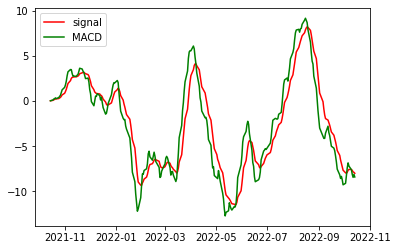

In [69]:
plt.plot(data.signal, label='signal', color='red')
plt.plot(data.MACD, label='MACD', color='green')
plt.legend()
plt.show()

In [70]:
Buy, Sell = [], []

for i in range(3, len(data)):
#dadurch prüft code für jede Zeile zwischen 2 und ende des datensatzes ob die IF-Statements stimmen    
    
    if data.MACD.iloc[i] > data.signal.iloc[i] and data.MACD.iloc[i-1] < data.signal.iloc[i-1]:
        Buy.append(i)
        # 'iloc' gibt die location von i an. I sind die Zeilen des Datensatzes. 
        # Wenn also MACD in Zeile i GRÖ?ER ist als Signal in Zeile I UND 
        # in der Zeile davor also am Tag davor (i-1) Signal GRÖ?ER war als MACD wird gekauft
    
    if data.MACD.iloc[i] < data.signal.iloc[i] and data.MACD.iloc[i-1] > data.signal.iloc[i-1]:
        Sell.append(i)
        # 'iloc' gibt die location von i an. I sind die Zeilen des Datensatzes. 
        # Wenn also MACD in Zeile i KLEINER ist als Signal in Zeile I UND 
        # in der Zeile davor also am Tag davor (i-1) Signal KLEINER war als MACD wird gekauft

In [71]:
Buy
#zeigt an in welchen Reihen ein Buy signal vorliegt

[48, 75, 92, 104, 153, 173, 244]

In [81]:
Sell
#zeigt an in welcher Zeile ein Sell signal vorliegt
#zeigt, dass Probleme auftreten können weiter unten.
#hier wird nur die LONG-Strategie getestet. Da wir ein Sell-signal in Zeile 8 haben
#und ein Buy Signal erst in Zeile 12, wird das einen Fehler rausschmeißen
#daher codezeile 50 einbauen

[29, 56, 87, 97, 121, 165, 212, 247]

In [76]:
#Indikatoren werden ja anhand der Close prices berechnet. D.h. um zu kaufen und zu verkaufen
#werden erst am Openprice des Folgetages möglich

Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

Buyprices = data.Open.iloc[Realbuys]
Sellprices = data.Open.iloc[Realsells]

In [77]:
Buyprices

Date
2021-12-27    396.283003
2022-02-03    356.759155
2022-03-01    344.042283
2022-03-17    336.698743
2022-05-26    289.362776
2022-06-27    295.469004
2022-10-06    280.959991
Name: Open, dtype: float64

In [78]:
#wenn das 1. signal von Sellprices (Sellprice[0]) einen kleineren Index hat als das 1. Kaufsignal (Buyprice[0]) dann möchten wir diesen Index droppen
#wenn erste Zahl in der Zeile wo ich nur "sell" geschrieben habe, kleiner ist als erste Zahl der Code zeile wo ich nur "buy" geschrieben habe, droppen
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])

#wenn das letzte kaufsignal (Buyprices[-1]) einen höheren Index hat (also in einer späteren Zeile kommt) als das letzte Verkaufssignal (Sellprice[-1]) möchten wir dieses Signal droppen
#wenn letzte Zahl in der Zeile wo ich nur "Buy" geschrieben habe, größer ist als letzte Zahl der Code zeile wo 
elif Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Sellprices.index[-1])

In [79]:
profitsrel = []

for i in range(len(Buyprices)):
    profitsrel.append((Sellprices[i]-Buyprices[i])/Buyprices[i])

In [80]:
profit = sum(profitsrel)
print (profit)
#aus irgendeinem Grund habe ich hier einen profit von 0. irgendwo im Code muss ich einen Fehler haben

-0.16397526888434746
